In [255]:
import MDAnalysis as mda
import prolif as plf
from rdkit import Chem
import os
from collections import defaultdict
import pandas as pd
import sys
import json
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, RepeatedStratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, confusion_matrix
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
import matplotlib.pyplot as plt
from decimal import Decimal
from rdkit.ML.Scoring.Scoring import CalcBEDROC
from scipy.integrate import trapezoid
from scipy import stats

## Metrics

In [244]:
def enrichment_factor(df: pd.DataFrame, fraction: float) -> float:
    df = df.sort_values("score", ascending=False)

    n_total = len(df)
    n_top = max(1, int(np.ceil(n_total * fraction)))


    n_actives = df["active"].sum()
    n_actives_in_top = df.head(n_top)["active"].sum()

    return (
        (n_actives_in_top / n_top)
        /
        (n_actives / n_total)
    )

def bedroc(df: pd.DataFrame, col: int, alpha: float) -> float:
    bedroc = CalcBEDROC(
        list(zip(df["score"], df["active"])),
        col=col,
        alpha=alpha
    )
    return bedroc

# Adapted from Oscar's notebook
def interpolate_curve(points):
    i = 0
    while i < len(points) and points[i][0] == 0:
        i += 1
    slope = (points[i][1] - points[i-1][1])/(points[i][0] - points[i-1][0])
    intercept = points[i][1] - slope * points[i][0]
    point_one =  [0.100001, (slope * 0.100001 + intercept)]
    npoints = [x for x in points]
    npoints.insert(i, point_one)
    return npoints

def logAUC(y_true, y_pred) -> float:
    # constants
	## If you modify also change in plots.py
    LOGAUC_MAX = 1.0 ## this should not change
    LOGAUC_MIN = 0.001 ## this you may want to change if your database is large and you have strong early enrichment.
    RANDOM_LOGAUC = (LOGAUC_MAX-LOGAUC_MIN)/np.log(10)/np.log10(LOGAUC_MAX/LOGAUC_MIN)

    fpr, tpr, _ = roc_curve(y_true, y_pred)
    points = list(zip(fpr*100, tpr*100))
    points = interpolate_curve(points)


	# assumes we have previously interpolated to get y-value at x = 0.1% 
	# generate new points array clamped between 0.1% and 100%
    npoints = []
    for x in points:
        if (x[0] >= LOGAUC_MIN*100) and (x[0] <= LOGAUC_MAX*100):
            npoints.append( [x[0]/100, x[1]/100] )

    area = 0.0
    for point2, point1 in zip(npoints[1:], npoints[:-1]):
        if point2[0] - point1[0] < 0.000001:
            continue

        # segment area computed as integral of log transformed equation
        dx = point2[0]-point1[0]
        dy = point2[1]-point1[1]
        intercept = point2[1] - dy/dx * point2[0]
        area += dy/np.log(10) + intercept*(np.log10(point2[0])-np.log10(point1[0]))

    return area / np.log10(LOGAUC_MAX/LOGAUC_MIN) - RANDOM_LOGAUC

def logAUC_OSCAR(points):
    # constants
	## if you modify also change in plots.py        
	LOGAUC_MAX = 1.0   ## this should not change
	LOGAUC_MIN = 0.001 ## this you may want to change if you database is large and you have strong early enrichment. 
	RANDOM_LOGAUC = (LOGAUC_MAX-LOGAUC_MIN)/np.log(10)/np.log10(LOGAUC_MAX/LOGAUC_MIN)


	"""Compute semilog x AUC minus the perfectly random semilog AUC."""
	# assumes we have previously interpolated to get y-value at x = 0.1% 
	# generate new points array clamped between 0.1% and 100%

	npoints = []
	for x in points:
		if (x[0] >= LOGAUC_MIN*100) and (x[0] <= LOGAUC_MAX*100):
			npoints.append( [x[0]/100 , x[1]/100] )

	area = 0.0
	for point2, point1 in zip(npoints[1:], npoints[:-1]):
		if point2[0] - point1[0] < 0.000001:
			continue

		# segment area computed as integral of log transformed equation
		dx = point2[0]-point1[0]
		dy = point2[1]-point1[1]
		intercept = point2[1] - (dy)/(dx) * point2[0]
		area += dy/np.log(10) + intercept*(np.log10(point2[0])-np.log10(point1[0]))

	# print("logAUC", area, area/np.log10(LOGAUC_MAX/LOGAUC_MIN) - RANDOM_LOGAUC)
	return area/np.log10(LOGAUC_MAX/LOGAUC_MIN) - RANDOM_LOGAUC
    

# Loading and cleaning data

In [2]:
# Import all pickled IFP dictionaries from prolif_fps directory

IFP_pickles = [file for file in os.listdir('./prolif_fps') if file.endswith('.pkl')]

IFP_dicts = {}

for pickle in IFP_pickles:
    temp_dict = pd.read_pickle(f"./prolif_fps/{pickle}")
    key = list(temp_dict.keys())[0]
    IFP_dicts[key] = temp_dict[key]



# Clean up column levels

for run_key, run_dict in IFP_dicts.items():
    for conformer_key, conformer_dict in IFP_dicts[run_key].items():
        for ligand_key, ligand_list in IFP_dicts[run_key][conformer_key].items():
            # remove superfluous ligand columns level 
            ligand_list[1].columns = ligand_list[1].columns.droplevel("ligand")
            # merge protein and interaction column level
            ligand_list[1].columns = ligand_list[1].columns.map("_".join)
            if "_" in ligand_list[1].columns:
                ligand_list[1].rename(columns={'_': 'LigName'}, inplace=True)

## Summary stats of IFP counts, enrichments

In [3]:
IFP_frequencies = {}

for run_key, run_dict in IFP_dicts.items():
    IFP_frequencies[run_key] = {}

    for conformer_key, conformer_dict in IFP_dicts[run_key].items():

        ligand_keys = list(conformer_dict.keys())
        actives_key = [key for key in ligand_keys if key.endswith("true_actives.sdf")][0]
        inactives_key = [key for key in ligand_keys if key.endswith("true_inactives.sdf")][0]
        decoys_key = [key for key in ligand_keys if key.endswith("decoys.sdf")][0]

        actives = IFP_dicts[run_key][conformer_key][actives_key][1].copy()
        if 'LigName' in actives.columns:
            actives.drop('LigName', axis=1, inplace=True)
        freq_actives = actives.mean(axis=0)
        freq_actives.name = 'freq_actives'

        inactives = IFP_dicts[run_key][conformer_key][inactives_key][1].copy()
        if 'LigName' in inactives.columns:
            inactives.drop('LigName', axis=1, inplace=True)
        freq_inactives = inactives.mean(axis=0)
        freq_inactives.name = 'freq_inactives'

        decoys = IFP_dicts[run_key][conformer_key][decoys_key][1].copy()
        if 'LigName' in decoys.columns:
            decoys.drop('LigName', axis=1, inplace=True)
        freq_decoys = decoys.mean(axis=0)
        freq_decoys.name = 'freq_decoys'

        new_df = pd.concat(
            [
                freq_actives.rename("freq_actives"),
                freq_inactives.rename("freq_inactives"),
                freq_decoys.rename("freq_decoys"),

            ],
            axis = 1
        )

        new_df['ER_actives_decoys'] = new_df['freq_actives'] / new_df['freq_decoys']
        new_df['Log2_ER_actives_decoys'] = np.log2(new_df['ER_actives_decoys'])

        new_df['ER_actives_inactives'] = new_df['freq_actives'] / new_df['freq_inactives']
        new_df['Log2_ER_actives_inactives'] = np.log2(new_df['ER_actives_inactives'])
        
        IFP_frequencies[run_key][conformer_key] = new_df



In [5]:
IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf']

,freq_actives,freq_inactives,freq_decoys,ER_actives_decoys,Log2_ER_actives_decoys,ER_actives_inactives,Log2_ER_actives_inactives
LEU363.A_VdWContact,0.070175,0.059524,0.161109,0.435578,-1.198997,1.178947,0.237499
ASP366.A_Hydrophobic,0.192982,0.250000,0.372447,0.518148,-0.948565,0.771930,-0.373458
ASP366.A_VdWContact,0.333333,0.583333,0.711755,0.468326,-1.094415,0.571429,-0.807355
ILE369.A_Hydrophobic,0.245614,0.202381,0.190079,1.292167,0.369792,1.213622,0.279319
ILE369.A_VdWContact,0.438596,0.452381,0.493122,0.889428,-0.169051,0.969529,-0.044644
...,...,...,...,...,...,...,...
ARG545.B_Anionic,NaN,NaN,0.007712,NaN,NaN,NaN,NaN
ARG545.B_PiCation,NaN,NaN,0.008962,NaN,NaN,NaN,NaN
LYS547.B_Hydrophobic,NaN,NaN,0.005836,NaN,NaN,NaN,NaN
LYS547.B_Anionic,NaN,NaN,0.043977,NaN,NaN,NaN,NaN


In [6]:
df = IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf'].dropna()
df.sort_values(by='freq_actives', ascending=False).head()


,freq_actives,freq_inactives,freq_decoys,ER_actives_decoys,Log2_ER_actives_decoys,ER_actives_inactives,Log2_ER_actives_inactives
GLU543.B_VdWContact,0.982456,0.928571,0.871822,1.126900,0.172360,1.058030,0.081380
GLU543.A_VdWContact,0.982456,0.940476,0.895790,1.096748,0.133233,1.044637,0.063002
GLU543.A_Hydrophobic,0.947368,0.785714,0.547937,1.728974,0.789917,1.205742,0.269921
GLU543.B_Hydrophobic,0.947368,0.928571,0.696332,1.360513,0.444151,1.020243,0.028913
HIS456.B_VdWContact,0.736842,0.571429,0.445602,1.653587,0.725599,1.289474,0.366782


## Binary Logistic regression model to find IFP weights

In [282]:
montpellier_ligand_data = pd.read_csv("./results/montpellier_ligands.csv")
true_actives = montpellier_ligand_data[montpellier_ligand_data["ACTIVE_LABEL"] == True]["ID"].tolist()
#true_actives_ligand_names = true_actives["ID"].tolist()

# 4H2I_C_4

actives_docking_4h2i_c_4 = pd.read_csv("./results/12Jun_rg/all_montpellier_4h2i_c_4_dimer.csv")[["LigName", "docking_score"]]
actives_docking_4h2i_c_4 = actives_docking_4h2i_c_4[actives_docking_4h2i_c_4["LigName"].isin(true_actives)]

actives_4h2i_c_4 = IFP_dicts['12Jun_rg']['4h2i_c_4_dimer_sdf']['4h2i_c_4_dimer_true_actives.sdf'][1]
actives_4h2i_c_4['Active'] = True
actives_4h2i_c_4 = actives_4h2i_c_4.merge(actives_docking_4h2i_c_4, on="LigName")

decoys_docking_4h2i_c_4 = pd.read_csv("./results/12Jun_rg/all_decoys_4h2i_c_4_dimer.csv")[["LigName", "docking_score"]]
decoys_4h2i_c_4 = IFP_dicts['12Jun_rg']['4h2i_c_4_dimer_sdf']['4h2i_c_4_dimer_decoys.sdf'][1]
decoys_4h2i_c_4['Active'] = False
decoys_4h2i_c_4 = decoys_4h2i_c_4.merge(decoys_docking_4h2i_c_4, on="LigName")

# 6TVE_C_1

actives_docking_6tve_c_1 = pd.read_csv("./results/12Jun_rg/all_montpellier_6tve_c_1_dimer.csv")[["LigName", "docking_score"]]
actives_docking_6tve_c_1 = actives_docking_6tve_c_1[actives_docking_6tve_c_1["LigName"].isin(true_actives)]

actives_6tve_c_1 = IFP_dicts['12Jun_rg']['6tve_c_1_dimer_sdf']['6tve_c_1_dimer_true_actives.sdf'][1]
actives_6tve_c_1['Active'] = True
actives_6tve_c_1 = actives_6tve_c_1.merge(actives_docking_6tve_c_1, on="LigName")

decoys_docking_6tve_c_1 = pd.read_csv("./results/12Jun_rg/all_decoys_6tve_c_1_dimer.csv")[["LigName", "docking_score"]]
decoys_6tve_c_1 = IFP_dicts['12Jun_rg']['6tve_c_1_dimer_sdf']['6tve_c_1_dimer_decoys.sdf'][1]
decoys_6tve_c_1['Active'] = False
decoys_6tve_c_1 = decoys_6tve_c_1.merge(decoys_docking_6tve_c_1, on="LigName")

# 6TVE_C_2

actives_docking_6tve_c_2 = pd.read_csv("./results/12Jun_rg/all_montpellier_6tve_c_2_dimer.csv")[["LigName", "docking_score"]]
actives_docking_6tve_c_2 = actives_docking_6tve_c_2[actives_docking_6tve_c_2["LigName"].isin(true_actives)]

actives_6tve_c_2 = IFP_dicts['12Jun_rg']['6tve_c_2_dimer_sdf']['6tve_c_2_dimer_true_actives.sdf'][1]
actives_6tve_c_2['Active'] = True
actives_6tve_c_2 = actives_6tve_c_2.merge(actives_docking_6tve_c_2, on="LigName")

decoys_docking_6tve_c_2 = pd.read_csv("./results/12Jun_rg/all_decoys_6tve_c_2_dimer.csv")[["LigName", "docking_score"]]
decoys_6tve_c_2 = IFP_dicts['12Jun_rg']['6tve_c_2_dimer_sdf']['6tve_c_2_dimer_decoys.sdf'][1]
decoys_6tve_c_2['Active'] = False
decoys_6tve_c_2 = decoys_6tve_c_2.merge(decoys_docking_6tve_c_1, on="LigName")

datasets = {
    "4h2i_c_4": {"actives": actives_4h2i_c_4, "decoys": decoys_4h2i_c_4},
    "6tve_c_1": {"actives": actives_6tve_c_1, "decoys": decoys_6tve_c_2},
    "6tve_c_2": {"actives": actives_6tve_c_2, "decoys": decoys_6tve_c_2}
}


In [314]:
model_inputs = {}

for conformer_key, dataset in datasets.items():
    print("\n")
    print(f"Dataframe information for {conformer_key}")
    print(f"shape actives: {dataset['actives'].shape}")
    print(f"shape decoys: {dataset['decoys'].shape}")

    # Check if all IFP columns in actives are present in decoys
    set_a = set(dataset['actives'].columns)
    set_d = set(dataset['decoys'].columns)

    both = set_a.intersection(set_d)
    print(f"All IFP columns in 'active' present in 'decoy': {set_a == both}")

    d_not_a = set_d - set_a
    a_not_d = set_a - set_d
    print(f"Number of IFP columns in 'decoy' not present in 'active': {len(d_not_a)}")
    print(f"Number of IFP columns in 'active' not present in 'decoy': {len(a_not_d)}: {a_not_d}")

    # columns_decoys_in_active = dataset['decoys'].drop(columns=d_not_a)
    # print(f"Shape decoys after removing columns not present in 'active': {columns_decoys_in_active.shape}")

    actives = dataset["actives"]
    decoys = dataset["decoys"]
    all_columns = actives.columns.union(decoys.columns)
    actives = actives.reindex(columns=all_columns, fill_value=False)
    decoys = decoys.reindex(columns=all_columns, fill_value=False)

    all = pd.concat([actives, decoys], ignore_index=True)
    print(f"Shape of combined df: {all.shape}")

    X_IFP = all.drop(columns=["Active", "LigName", "docking_score"])
    X_DOCKING = pd.DataFrame(all['docking_score'])
    X_IFP_DOCKING = all.drop(columns=["Active", "LigName"])
    Y = all["Active"]

    model_inputs[conformer_key] = {
        "X": {"X_IFP": X_IFP, "X_DOCKING": X_DOCKING, "X_IFP_DOCKING": X_IFP_DOCKING},
        "Y": Y
    }



Dataframe information for 4h2i_c_4
shape actives: (57, 67)
shape decoys: (4798, 191)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 124
Number of IFP columns in 'active' not present in 'decoy': 0: set()
Shape of combined df: (4855, 191)


Dataframe information for 6tve_c_1
shape actives: (57, 67)
shape decoys: (4798, 180)
All IFP columns in 'active' present in 'decoy': False
Number of IFP columns in 'decoy' not present in 'active': 114
Number of IFP columns in 'active' not present in 'decoy': 1: {'HIS456.A_CationPi'}
Shape of combined df: (4855, 181)


Dataframe information for 6tve_c_2
shape actives: (57, 71)
shape decoys: (4798, 180)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 109
Number of IFP columns in 'active' not present in 'decoy': 0: set()
Shape of combined df: (4855, 180)


### Only IFPs

In [280]:
print(f"shape actives: {actives_4h2i_c_4.shape}")
print(f"shape decoys: {decoys_4h2i_c_4.shape}")

# Check if all IFP columns in actives are present in decoys
set_a = set(actives_4h2i_c_4.columns)
set_d = set(decoys_4h2i_c_4.columns)

both = set_a.intersection(set_d)
print(f"All IFP columns in 'active' present in 'decoy': {set_a == both}")

d_not_a = set_d ^ set_a
print(f"Number of IFP columns in 'decoy' not present in 'active': {len(d_not_a)}")

decoys_4h2i_c_4_not_active = decoys_4h2i_c_4.drop(columns=d_not_a)
print(f"Shape decoys after removing columns not present in 'active': {decoys_4h2i_c_4_not_active.shape}")

all_4h2i_c_4 = pd.concat([actives_4h2i_c_4, decoys_4h2i_c_4_not_active])
print(f"Shape of combined df: {all_4h2i_c_4.shape}")

X_4h2i_c_4_IFP = all_4h2i_c_4.drop(columns=["Active", "LigName", "docking_score"])
X_4h2i_c_4_DOCKING = pd.DataFrame(all_4h2i_c_4['docking_score'])
X_4h2i_c_4_IFP_DOCKING = all_4h2i_c_4.drop(columns=["Active", "LigName"])
Y_4h2i_c_4 = all_4h2i_c_4["Active"]

shape actives: (57, 67)
shape decoys: (4798, 191)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 124
Shape decoys after removing columns not present in 'active': (4798, 67)
Shape of combined df: (4855, 67)


## Hyperparameter tuning with cross validation to pick regularization strength (C)
For three conformers

- Choose C
- Fit logistic regression
- Estimate performance with CV
- Compare models



In [ ]:
for cv.split(X, Y)

<generator object _BaseKFold.split at 0x18fb04040>

In [316]:
for conformer in model_inputs:
    print(model_inputs[conformer].keys())
    print(model_inputs[conformer]["X"].keys())

dict_keys(['X', 'Y'])
dict_keys(['X_IFP', 'X_DOCKING', 'X_IFP_DOCKING'])
dict_keys(['X', 'Y'])
dict_keys(['X_IFP', 'X_DOCKING', 'X_IFP_DOCKING'])
dict_keys(['X', 'Y'])
dict_keys(['X_IFP', 'X_DOCKING', 'X_IFP_DOCKING'])


In [342]:
Cs = np.logspace(-3, 3, 13)

all_results = {}
all_coef_results = {}

for conformer_key, model_input in model_inputs.items():

    print(f"Running models for {conformer_key}")

    Y = model_input["Y"]

    # Loop over different feature sets (IFPs, docking, IFPs + docking)
    for X_key, X in model_input["X"].items():

        print(f"Running models for {X_key}")

        dataset_name = f"{conformer_key}_{X_key}"

        results = []
        coef_results = {}

        # Check if docking_score column is present in X to change scaling preprocessor accordingly
        has_docking = "docking_score" in X.columns

        if has_docking:
            preprocessor = ColumnTransformer(
                transformers=[
                    ("dock", StandardScaler(), ["docking_score"])
                ],
                remainder="passthrough",
            )
        else:
            preprocessor = "passthrough"

        # Loop over C(=1/lambda)s -> different regularization strength for cross validation
        for C in Cs:

            clf = Pipeline([
                ("preprocessor", preprocessor),
                ("lr", LogisticRegression(
                    l1_ratio=0, # l2 ridge
                    C=C,
                    max_iter=5000,
                    solver="lbfgs",
                    class_weight="balanced",
                )),
            ])

            # Stratified CV (= keeps active/decoy ratio balanced)
            cv = StratifiedKFold(
                n_splits=5,
                shuffle=True,
                random_state=42,
            )

            Y_true = np.empty(len(Y))
            Y_pred = np.empty(len(Y))
            coefs = []

            for train_idx, test_idx in cv.split(X, Y):
                # fit logistic regression model on training data (4 folds)
                clf.fit(X.iloc[train_idx], Y.iloc[train_idx])

                # store coefficients for each fold
                coefs.append(clf.named_steps["lr"].coef_[0])

                # make predictions on test fold, filling up the Y_true and Y_pred with each of the 5 folds
                Y_true[test_idx] = Y.iloc[test_idx]
                Y_pred[test_idx] = clf.predict_proba(X.iloc[test_idx])[:, 1]

            ranking = pd.DataFrame({
                "active": Y_true,
                "score": Y_pred,
            }).sort_values("score", ascending=False)

            # Calculate metrics for all predicted ligands
            results.append({
                "C": C,
                "AUC": roc_auc_score(ranking["active"], ranking["score"]),
                "logAUC": logAUC(ranking["active"], ranking["score"]),
                "EF1%": enrichment_factor(
                    df=ranking,
                    fraction=0.01,
                ),
                "EF0.1%": enrichment_factor(
                    df=ranking,
                    fraction=0.001,
                ),
                "BEDROC_80": bedroc(
                    df=ranking,
                    col=1,
                    alpha=80,
                ),
            })

            if has_docking:
                feature_names = clf.named_steps[
                    "preprocessor"
                ].get_feature_names_out()
            else:
                feature_names = X.columns

            # Average coefficients of 5 fold into mean, sd for current C-value
            coefs = np.array(coefs)

            coef_mean = np.mean(coefs, axis=0)
            coef_sd = np.std(coefs, axis=0)
            odds_ratio = np.exp(coef_mean)
            sign_consistency = np.mean(coefs > 0, axis=0)


            coef_df = pd.DataFrame({
                "label": feature_names,
                "coef_mean": coef_mean, # estimate of "true" coefficient
                "coef_sd": coef_sd, # stability of coefficient across folds
                "coef_mean/sd": abs(coef_mean) / coef_sd,
                "odds_ratio": odds_ratio,
                "sign_consistency": sign_consistency,
                "l2_norm": np.linalg.norm(coefs),
            })

            coef_results[C] = coef_df.sort_values(
                "coef_mean/sd",
                ascending=False,
            )

        all_results[dataset_name] = pd.DataFrame(results)
        all_coef_results[dataset_name] = coef_results

Running models for 4h2i_c_4
Running models for X_IFP
Running models for X_DOCKING
Running models for X_IFP_DOCKING
Running models for 6tve_c_1
Running models for X_IFP
Running models for X_DOCKING
Running models for X_IFP_DOCKING
Running models for 6tve_c_2
Running models for X_IFP
Running models for X_DOCKING
Running models for X_IFP_DOCKING


In [334]:
coef_results[0.001]

,label,coef_mean,coef_sd,coef_mean/sd
50,remainder__GLU543.A_Hydrophobic,0.192013,0.008816,21.779017
74,remainder__HIS456.B_PiStacking,0.165058,0.010218,16.152928
54,remainder__GLU543.B_Hydrophobic,0.139335,0.014322,9.728847
112,remainder__LYS547.A_VdWContact,0.176640,0.021446,8.236509
156,remainder__TYR539.B_Hydrophobic,0.103359,0.016493,6.266874
...,...,...,...,...
28,remainder__ASP366.B_HBDonor,-0.021159,0.000347,-60.988630
48,remainder__GLU543.A_Cationic,-0.088753,0.001378,-64.387938
134,remainder__TYR484.A_HBDonor,-0.061374,0.000855,-71.789812
155,remainder__TYR539.B_HBDonor,-0.047908,0.000607,-78.907547


In [322]:
all_results['4h2i_c_4_X_DOCKING']

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.537784,0.022095,1.738274,0.0,0.029116
1,0.003162,0.537741,0.022516,1.738274,0.0,0.029147
2,0.010000,0.537828,0.022747,1.738274,0.0,0.029084
3,0.031623,0.537784,0.022524,1.738274,0.0,0.029147
4,0.100000,0.537828,0.022531,1.738274,0.0,0.029147
5,0.316228,0.534325,0.011371,1.738274,0.0,0.022119
6,1.000000,0.537828,0.024243,1.738274,0.0,0.029078
7,3.162278,0.527319,0.024786,1.738274,0.0,0.037533
8,10.000000,0.537828,0.022531,1.738274,0.0,0.029147
9,31.622777,0.537828,0.022531,1.738274,0.0,0.029147


In [323]:
all_results['4h2i_c_4_X_IFP']

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.900148,0.331737,13.906194,17.035088,0.286908
1,0.003162,0.915425,0.366548,26.074114,34.070175,0.344032
2,0.010000,0.926022,0.394062,27.812388,34.070175,0.382951
3,0.031623,0.930187,0.407857,27.812388,51.105263,0.405561
4,0.100000,0.929612,0.412580,22.597565,51.105263,0.408850
5,0.316228,0.926318,0.402904,24.335840,34.070175,0.400711
6,1.000000,0.920669,0.390851,26.074114,34.070175,0.386118
7,3.162278,0.911290,0.374161,24.335840,34.070175,0.370645
8,10.000000,0.900046,0.356077,26.074114,34.070175,0.352242
9,31.622777,0.890634,0.339932,24.335840,34.070175,0.329468


In [324]:
all_results['4h2i_c_4_X_IFP_DOCKING']

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.900426,0.332555,13.906194,17.035088,0.288586
1,0.003162,0.915707,0.368161,26.074114,34.070175,0.346217
2,0.010000,0.926230,0.395745,29.550662,34.070175,0.384853
3,0.031623,0.930483,0.408388,27.812388,51.105263,0.406428
4,0.100000,0.929580,0.411491,22.597565,51.105263,0.407246
5,0.316228,0.926402,0.402062,24.335840,34.070175,0.399576
6,1.000000,0.920903,0.391068,26.074114,34.070175,0.386145
7,3.162278,0.911418,0.374191,24.335840,34.070175,0.370152
8,10.000000,0.900116,0.356155,26.074114,34.070175,0.351711
9,31.622777,0.891186,0.341475,24.335840,34.070175,0.331614


In [325]:
# Cs = np.logspace(-3, 3, 13)

# all_results = {}
# all_coef_results = {}


# for conformer_key, model_input in model_inputs.items():
#     print(f"Running models for {conformer_key}")

#     for X_key, X in model_input["X"].items():
#         print(f"Running models for {X_key}")
#         dataset_name = f"{conformer_key}_{X_key}"
        
#         Y = model_input['Y']
#         results = []
#         coef_results = {}

#         has_docking = "docking_score" in X.columns

#         if has_docking:
#             preprocessor = ColumnTransformer(
#                 transformers=[
#                     ("dock", StandardScaler(), ["docking_score"])
#                 ],
#                 remainder="passthrough"
#             )
#         else:
#             preprocessor = "passthrough"

#         for C in Cs:

#             clf = Pipeline([
#                 ("preprocessor", preprocessor),
#                 ("lr", LogisticRegression(
#                     penalty="l2",
#                     C=C,
#                     solver="lbfgs",
#                     class_weight="balanced",
#                 )),
#             ])

#             cv = StratifiedKFold(
#                 n_splits=5,
#                 shuffle=True,
#                 random_state=42,
#             )

#             Y_true = np.empty(len(Y_4h2i_c_4))
#             Y_pred = np.empty(len(Y_4h2i_c_4))
#             coefs = []

#             for train_idx, test_idx in cv.split(X, Y_4h2i_c_4):

#                 clf.fit(X.iloc[train_idx], Y_4h2i_c_4.iloc[train_idx])

#                 coefs.append(clf.named_steps["lr"].coef_[0])

#                 Y_true[test_idx] = Y.iloc[test_idx]
#                 Y_pred[test_idx] = clf.predict_proba(X.iloc[test_idx])[:, 1]

#                 ranking = pd.DataFrame({
#                     "active": Y_true,
#                 "score": Y_pred,
#                 })

#                 results.append({
#                     "C": C,
#                     "AUC": roc_auc_score(ranking["active"], ranking["score"]),
#                     "logAUC": logAUC(ranking["active"], ranking["score"]),
#                     "EF1%": enrichment_factor(
#                         df=ranking.sort_values("score", ascending=False),
#                         fraction=0.01,
#                     ),
#                     "EF0.1%": enrichment_factor(
#                         df=ranking.sort_values("score", ascending=False),
#                         fraction=0.001,
#                     ),
#                     "BEDROC_80": bedroc(
#                         df=ranking.sort_values("score", ascending=False),
#                         col=1,
#                         alpha=80,
#                     ),
#                 })

#                 if has_docking:
#                     feature_names = clf.named_steps["preprocessor"].get_feature_names_out()
#                 else:
#                     feature_names = X.columns

#                 coef_results[C] = pd.DataFrame({
#                     "label": feature_names,
#                     "coef_mean": np.mean(coefs, axis=0),
#                     "coef_sd": np.std(coefs, axis=0),
#                 })

#                 coef_results[C]["coef_mean/sd"] = (
#                     coef_results[C]["coef_mean"] /
#                     coef_results[C]["coef_sd"]
#                 )

#                 coef_results[C] = coef_results[C].sort_values(
#                     "coef_mean/sd",
#                     ascending=False,
#                 )

#             all_results[dataset_name] = pd.DataFrame(results)
#             all_coef_results[dataset_name] = coef_results

In [310]:
all_results['4h2i_c_4_2']

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.900426,0.332555,13.906194,17.035088,0.288586
1,0.003162,0.915707,0.368161,26.074114,34.070175,0.346217
2,0.010000,0.926230,0.395745,29.550662,34.070175,0.384853
3,0.031623,0.930483,0.408388,27.812388,51.105263,0.406428
4,0.100000,0.929580,0.411491,22.597565,51.105263,0.407246
5,0.316228,0.926402,0.402062,24.335840,34.070175,0.399576
6,1.000000,0.920903,0.391068,26.074114,34.070175,0.386145
7,3.162278,0.911418,0.374191,24.335840,34.070175,0.370152
8,10.000000,0.900116,0.356155,26.074114,34.070175,0.351711
9,31.622777,0.891186,0.341475,24.335840,34.070175,0.331614


In [275]:
all_results['IFP']

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.881361,0.294806,13.906194,17.035088,0.242037
1,0.003162,0.894276,0.326036,17.382743,17.035088,0.294365
2,0.010000,0.900894,0.347030,19.121017,17.035088,0.323837
3,0.031623,0.898053,0.356517,19.121017,17.035088,0.331366
4,0.100000,0.887775,0.346157,19.121017,34.070175,0.316502
5,0.316228,0.872487,0.326809,19.121017,34.070175,0.297141
6,1.000000,0.852727,0.301822,19.121017,34.070175,0.277894
7,3.162278,0.828595,0.279358,15.644468,34.070175,0.263081
8,10.000000,0.804710,0.261605,13.906194,34.070175,0.245926
9,31.622777,0.785057,0.246358,15.644468,34.070175,0.237954


In [276]:
all_results['IFP_DOCKING']

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.881669,0.295524,13.906194,17.035088,0.243423
1,0.003162,0.894605,0.326937,17.382743,17.035088,0.296300
2,0.010000,0.901249,0.348112,20.859291,17.035088,0.325979
3,0.031623,0.898335,0.355272,19.121017,17.035088,0.331766
4,0.100000,0.888100,0.346221,19.121017,34.070175,0.316276
5,0.316228,0.873017,0.327069,19.121017,34.070175,0.296921
6,1.000000,0.853020,0.302041,19.121017,34.070175,0.277530
7,3.162278,0.828141,0.279867,15.644468,34.070175,0.261929
8,10.000000,0.804860,0.261889,13.906194,34.070175,0.246528
9,31.622777,0.782804,0.245627,15.644468,34.070175,0.239578


In [277]:
all_results['DOCKING']

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.537784,0.022095,1.738274,0.0,0.029116
1,0.003162,0.537741,0.022516,1.738274,0.0,0.029147
2,0.010000,0.537828,0.022747,1.738274,0.0,0.029084
3,0.031623,0.537784,0.022524,1.738274,0.0,0.029147
4,0.100000,0.537828,0.022531,1.738274,0.0,0.029147
5,0.316228,0.534325,0.011371,1.738274,0.0,0.022119
6,1.000000,0.537828,0.024243,1.738274,0.0,0.029078
7,3.162278,0.527319,0.024786,1.738274,0.0,0.037533
8,10.000000,0.537828,0.022531,1.738274,0.0,0.029147
9,31.622777,0.537828,0.022531,1.738274,0.0,0.029147


Text(0, 0.5, 'Docking coefficient')

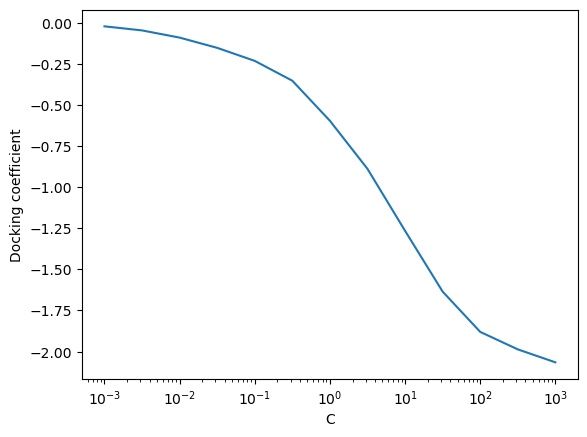

In [279]:
docking_coef = []

for C in Cs:
    df = coef_results[C]
    docking_coef.append(
        df.loc[df["label"].str.contains("docking"), "coef_mean"].iloc[0]
    )

plt.semilogx(Cs, docking_coef)
plt.xlabel("C")
plt.ylabel("Docking coefficient")

In [269]:
print("coef_results")
coef_results[0.100000]

coef_results


,label,coefs,coef_mean,coef_sd,coef_mean/sd,coefs_norm,coefs_max
34,remainder__ARG545.A_Hydrophobic,1.741364,1.741364,0.201677,8.634412,5.596255,1.812849
42,remainder__HIS456.B_PiStacking,1.812849,1.812849,0.226745,7.995108,5.596255,1.812849
30,remainder__GLU543.A_Hydrophobic,1.522710,1.522710,0.285704,5.329671,5.596255,1.812849
12,remainder__HIS456.A_PiStacking,1.038426,1.038426,0.196658,5.280369,5.596255,1.812849
57,remainder__TYR539.B_VdWContact,0.604676,0.604676,0.149842,4.035413,5.596255,1.812849
...,...,...,...,...,...,...,...
33,remainder__GLY544.A_VdWContact,-1.127923,-1.127923,0.180280,-6.256492,5.596255,1.812849
0,dock__docking_score,-0.231386,-0.231386,0.036571,-6.327020,5.596255,1.812849
52,remainder__TYR531.B_VdWContact,-0.934264,-0.934264,0.133667,-6.989500,5.596255,1.812849
31,remainder__GLU543.A_Cationic,-1.322451,-1.322451,0.163000,-8.113174,5.596255,1.812849


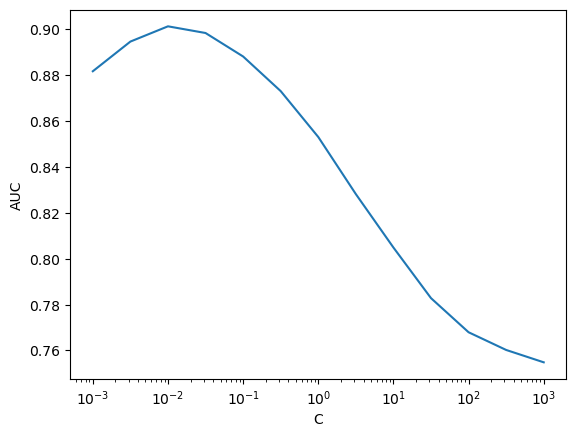

In [267]:
plt.plot([r["C"] for r in results], [r["AUC"] for r in results])
plt.xscale("log")
plt.xlabel("C")
plt.ylabel("AUC")
plt.show()

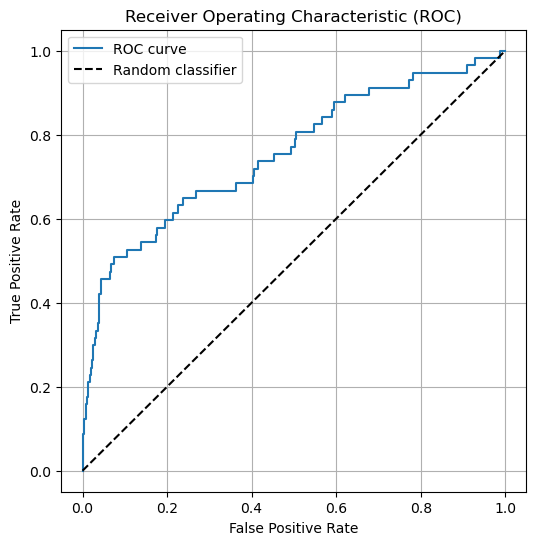

ROC AUC Score: 0.7548430266997213


In [278]:
# Cross validated ROC AUC -> How well will the model perform on unseen ligands 
fpr, tpr, thresholds = roc_curve(ranking["active"], ranking["score"])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)

plt.show()

print(f"ROC AUC Score: {roc_auc_score(Y_true, Y_pred)}")



/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1780: FutureWarning: The default value for l1_ratios will change from None to (0.0,) in version 1.10. From version 1.10 onwards, only array-like with values in [0, 1] will be allowed, None will be forbidden. To avoid this warning, explicitly set a value, e.g. l1_ratios=(0,).
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1811: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratios' instead. Use l1_ratios=(0,) instead of penalty='l2'  and l1_ratios=(1,) instead of penalty='l1'.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1823: FutureWarning: The fitted attributes of LogisticRegressionCV will be simpl

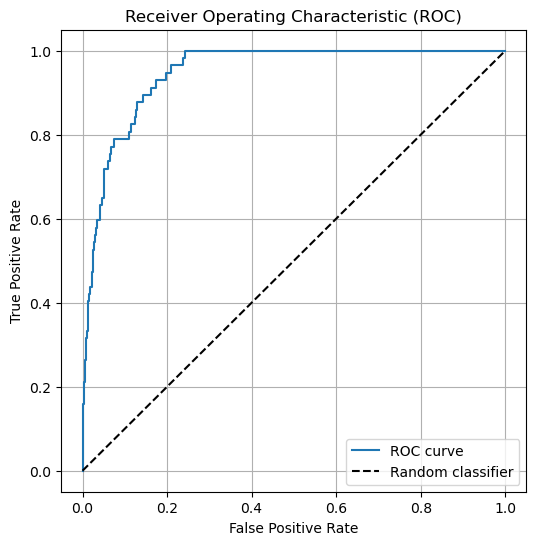

Training ROC AUC Score: 0.9478766737602656


In [38]:
# Training ROC AUC -> How well will the model perform on the training set (overfitting)
clf.fit(X_IFP, Y)

fpr, tpr, thresholds = roc_curve(Y, clf.predict_proba(X_IFP)[:, 1])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label="ROC curve")
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Receiver Operating Characteristic (ROC)")
plt.legend()
plt.grid(True)

plt.show()


train_auc = roc_auc_score(Y, clf.predict_proba(X_IFP)[:, 1])
print(f"Training ROC AUC Score: {train_auc}")

In [71]:
IFP_frequencies['12Jun_rg']['4h2i_c_4_dimer_sdf']

NameError: name 'IFP_frequencies' is not defined

## Include IFP and docking scores

In [ ]:
IFP_dicts['12Jun_rg']['4h2i_c_1_dimer_sdf']['4h2i_c_1_dimer_true_actives.sdf'][1].columns

## 6TVE_C_1

In [205]:
print(f"shape actives: {actives_6tve_c_1.shape}")
print(f"shape decoys: {decoys_6tve_c_1.shape}")

# Check if all IFP columns in actives are present in decoys
set_a = set(actives_6tve_c_1.columns)
set_d = set(decoys_6tve_c_1.columns)

both = set_a.intersection(set_d)
print(f"All IFP columns in 'active' present in 'decoy': {set_a == both}")

d_not_a = set_d ^ set_a
print(f"Number of IFP columns in 'decoy' not present in 'active': {len(d_not_a)}")

decoys_6tve_c_1_not_active = decoys_6tve_c_1.drop(columns=d_not_a)
print(f"Shape decoys after removing columns not present in 'active': {decoys_6tve_c_1_not_active.shape}")

all_6tve_c_1 = pd.concat([actives_6tve_c_1, decoys_6tve_c_1_not_active])
print(f"Shape of combined df: {all_6tve_c_1.shape}")

X_DOCKING = all_6tve_c_1[["docking_score"]]
X_IFP = all_6tve_c_1.drop(columns=["Active", "LigName", "docking_score"])
X_IFP_DOCKING_SCORE = all_6tve_c_1.drop(columns=["Active", "LigName"])
Y = all_6tve_c_1["Active"]

shape actives: (57, 67)
shape decoys: (4798, 176)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 109
Shape decoys after removing columns not present in 'active': (4798, 67)
Shape of combined df: (4855, 67)


In [206]:
Cs = np.logspace(-3, 3, 13)
Cs = [float(C) for C in Cs]

results = []
coef_results = {}

for C in Cs:
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        class_weight="balanced"
    )
    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    Y_true = []
    Y_pred = []
    coefs = []
    
    for train_idx, test_idx in cv.split(X_IFP_DOCKING_SCORE, Y):
        clf.fit(X_IFP_DOCKING_SCORE.iloc[train_idx], Y.iloc[train_idx])
        coefs.append(clf.coef_[0])
        p = clf.predict_proba(X_IFP_DOCKING_SCORE.iloc[test_idx])[:,1]
        Y_true.extend(Y.iloc[test_idx])
        Y_pred.extend(p)
    
    ranking = pd.DataFrame({
        "active": Y_true,
        "score": Y_pred
    }).sort_values("score", ascending=False)


    results.append({
        "C": C,
        "AUC": roc_auc_score(ranking["active"], ranking["score"]),
        "logAUC": log_auc2(ranking["active"], ranking["score"]),
        "EF1%": enrichment_factor(df=ranking, fraction=0.01),
        "EF0.1%": enrichment_factor(df=ranking, fraction=0.001),
        "BEDROC_80": bedroc(df=ranking, col=1, alpha=80),
    })


    coef_results[C] = pd.DataFrame({
        "label": X_IFP_DOCKING_SCORE.columns,
        "coefs": np.mean(coefs, axis=0),
        "coef_mean": np.mean(coefs, axis=0),
        "coef_sd": np.std(coefs, axis=0),
        "coef_mean/sd": np.mean(coefs, axis=0) / np.std(coefs, axis=0),
        "coefs_norm": np.linalg.norm(np.mean(coefs, axis=0)),
        "coefs_max": np.max(np.abs(np.mean(coefs, axis=0))),
    }).sort_values(by="coef_mean/sd", ascending=False)

results_df = pd.DataFrame(results)
results_df

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.761644,0.209415,13.906194,34.070175,0.225272
1,0.003162,0.773228,0.249441,20.859291,34.070175,0.293518
2,0.010000,0.778109,0.265038,22.597565,34.070175,0.314422
3,0.031623,0.773038,0.246134,17.382743,34.070175,0.265520
4,0.100000,0.763915,0.226896,12.167920,17.035088,0.217985
5,0.316228,0.754002,0.210351,10.429646,17.035088,0.183955
6,1.000000,0.742923,0.196629,8.691371,34.070175,0.156055
7,3.162278,0.734425,0.191170,8.691371,17.035088,0.149191
8,10.000000,0.725799,0.182891,8.691371,17.035088,0.142266
9,31.622777,0.722315,0.181311,8.691371,17.035088,0.139357


## 6TVE_C_2

In [207]:
print(f"shape actives: {actives_6tve_c_2.shape}")
print(f"shape decoys: {decoys_6tve_c_2.shape}")

# Check if all IFP columns in actives are present in decoys
set_a = set(actives_6tve_c_2.columns)
set_d = set(decoys_6tve_c_2.columns)

both = set_a.intersection(set_d)
print(f"All IFP columns in 'active' present in 'decoy': {set_a == both}")

d_not_a = set_d ^ set_a
print(f"Number of IFP columns in 'decoy' not present in 'active': {len(d_not_a)}")

decoys_6tve_c_2_not_active = decoys_6tve_c_2.drop(columns=d_not_a)
print(f"Shape decoys after removing columns not present in 'active': {decoys_6tve_c_2_not_active.shape}")

all_6tve_c_2 = pd.concat([actives_6tve_c_2, decoys_6tve_c_2_not_active])
print(f"Shape of combined df: {all_6tve_c_2.shape}")

X_DOCKING = all_6tve_c_2[["docking_score"]]
X_IFP = all_6tve_c_2.drop(columns=["Active", "LigName", "docking_score"])
X_IFP_DOCKING_SCORE = all_6tve_c_2.drop(columns=["Active", "LigName"])
Y = all_6tve_c_2["Active"]

shape actives: (57, 71)
shape decoys: (4798, 180)
All IFP columns in 'active' present in 'decoy': True
Number of IFP columns in 'decoy' not present in 'active': 109
Shape decoys after removing columns not present in 'active': (4798, 71)
Shape of combined df: (4855, 71)


In [208]:
Cs = np.logspace(-3, 3, 13)
Cs = [float(C) for C in Cs]

results = []
coef_results = {}

for C in Cs:
    clf = LogisticRegression(
        penalty="l2",
        C=C,
        solver="lbfgs",
        class_weight="balanced"
    )
    
    cv = StratifiedKFold(
        n_splits=5,
        shuffle=True,
        random_state=42
    )
    
    Y_true = []
    Y_pred = []
    coefs = []
    
    for train_idx, test_idx in cv.split(X_IFP_DOCKING_SCORE, Y):
        clf.fit(X_IFP_DOCKING_SCORE.iloc[train_idx], Y.iloc[train_idx])
        coefs.append(clf.coef_[0])
        p = clf.predict_proba(X_IFP_DOCKING_SCORE.iloc[test_idx])[:,1]
        Y_true.extend(Y.iloc[test_idx])
        Y_pred.extend(p)
    
    ranking = pd.DataFrame({
        "active": Y_true,
        "score": Y_pred
    }).sort_values("score", ascending=False)


    results.append({
        "C": C,
        "AUC": roc_auc_score(ranking["active"], ranking["score"]),
        "logAUC": log_auc2(ranking["active"], ranking["score"]),
        "EF1%": enrichment_factor(df=ranking, fraction=0.01),
        "EF0.1%": enrichment_factor(df=ranking, fraction=0.001),
        "BEDROC_80": bedroc(df=ranking, col=1, alpha=80),
    })


    coef_results[C] = pd.DataFrame({
        "label": X_IFP_DOCKING_SCORE.columns,
        "coefs": np.mean(coefs, axis=0),
        "coef_mean": np.mean(coefs, axis=0),
        "coef_sd": np.std(coefs, axis=0),
        "coef_mean/sd": np.mean(coefs, axis=0) / np.std(coefs, axis=0),
        "coefs_norm": np.linalg.norm(np.mean(coefs, axis=0)),
        "coefs_max": np.max(np.abs(np.mean(coefs, axis=0))),
    }).sort_values(by="coef_mean/sd", ascending=False)

results_df = pd.DataFrame(results)
results_df

/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 'penalty' was deprecated in version 1.8 and will be removed in 1.10. To avoid this warning, leave 'penalty' set to its default value and use 'l1_ratio' or 'C' instead. Use l1_ratio=0 instead of penalty='l2', l1_ratio=1 instead of penalty='l1', and C=np.inf instead of penalty=None.
  warnings.warn(
/Users/wes/.local/share/mamba/envs/mdanalysis_210/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:1135: FutureWarning: 

,C,AUC,logAUC,EF1%,EF0.1%,BEDROC_80
0,0.001000,0.820481,0.240502,13.906194,17.035088,0.217559
1,0.003162,0.830620,0.268288,15.644468,68.140351,0.263926
2,0.010000,0.832598,0.283949,19.121017,68.140351,0.296339
3,0.031623,0.825666,0.282921,17.382743,34.070175,0.291235
4,0.100000,0.811669,0.270690,17.382743,34.070175,0.280216
5,0.316228,0.793185,0.256356,15.644468,34.070175,0.263356
6,1.000000,0.772515,0.239903,15.644468,34.070175,0.252678
7,3.162278,0.756796,0.226155,13.906194,17.035088,0.238711
8,10.000000,0.740308,0.211476,13.906194,17.035088,0.230431
9,31.622777,0.737255,0.210572,13.906194,34.070175,0.224024
